# SVM: Aaron Eckhardt

In [ ]:
import numpy as np
import pandas as pd
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from google.colab import drive
import matplotlib.pyplot as plt
drive.mount('/content/drive')
data = pd.read_csv('/content/drive/MyDrive/sample_features_balanced.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## What is SVM?

A support vector machine is a supervised machine learning algorithm that I will be using to classify our drum samples. This means that I will specifically be performing support vector classification, which is a type of SVM that stands in contrast to other types like SVR. SVC works by finding a hyperplane that optimally separates two classes, with any new data points being classified according to which side of the hyperplane they are on.\
\
This hyperplane is found through comparisons between each data point, with the points closest to the hyperplane which are used in defining the position of the hyperplane acting as "support vectors". The number of support vectors as well as the method for comparisons between data points can be tweaked with various kernel functions, which essentially compare data points to a higher dimension transformation of other data points. To explore uses and limitations of support vector classifiers, I will first do a visual demonstration of a simple SVC implementation, then I will perform SVC with various adjustments to the input dataset.


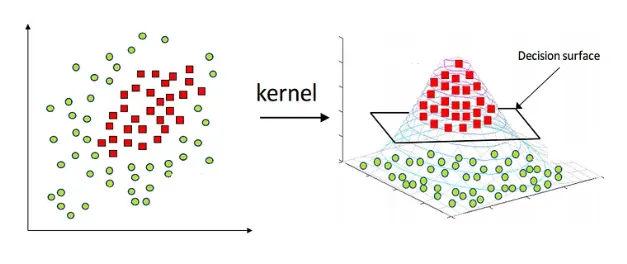\
Source: https://medium.com/@Suraj_Yadav/what-is-kernel-trick-in-svm-interview-questions-related-to-kernel-trick-97674401c48d


## SVM Visualization

While an infinite number of kernel functions exist, in practice only a select few are used. I demonstrated the use of a linear, polynomial, radial basis function, and sigmoid kernel in the code below. The linear kernel does not compare to transformed data at all, while the polynomial kernel simply compares to data scaled to the power of three. These two kernels are quite simple, which is in contrast to the RBF and sigmoid kernels. The RBF kernel can be thought of as similar to a k-nearest-neighbors algorithm, with the radial proximity of compared points being taken into account when generating the hyperplane. The sigmoid function operates similarly, but instead of radial proximity it scales by the hyperbolic tangent of compared points. Both the RBF and sigmoid kernels can have very irregular looking decision boundary shapes when graphed in two dimensions, with RBF often having more rounded boundaries and sigmoid having very sharply curvy boundary shapes. While the graphs below give the impression that the hyperplanes separating each class are curved, this is just a result of representing the individual comparisons between data points in two dimensions despite non-linear kernels comparing data points to higher dimensional transformations of other points.  \
\
This demonstration only uses the "core_frequency" and "average_activation" features from our dataset for easy visualization, as it is infeasible to neatly plot more features than that. This first demonstration is also a binary classification, classifying only classes with the labels "ride" and "hat". The use of two classes is done for the sake of neat visualization, as three or four classes had too much visual overlap in my early experimentation. One last thing to note about the setup of this demonstration is that the hat and ride drum sounds are generally quite similar sounding, on account both being cymbals.\
\
In addition to the visualizations in this first demonstration, I generated an accuracy value, confusion matrix, and a classification report for each kernel. These output statistics were also generated for the rest of the demonstrations. The accuracy value simply reports the average f1-score across classes (f1-score is explained below), while the confusion matrix shows how many points were classified as each class as well as how many of those classifications were accurate. The classification report statistics for each class are described as follows:\
\
Precision - Proportion of positive classifications that were correctly classified.\
Recall - Proportion of true positive classifications that were correctly classified.\
f1-score - Harmonic mean of precision and recall, which measures how well the model correctly classifies points while minimizing false positives.\
Support - The number of instances of a class in the test data.


Kernel: linear
Accuracy: 0.77
Confusion Matrix:
 [[22 10]
 [ 4 26]]
Classification Report:
               precision    recall  f1-score   support

        ride       0.85      0.69      0.76        32
         hat       0.72      0.87      0.79        30

    accuracy                           0.77        62
   macro avg       0.78      0.78      0.77        62
weighted avg       0.79      0.77      0.77        62


Kernel: poly
Accuracy: 0.74
Confusion Matrix:
 [[19 13]
 [ 3 27]]
Classification Report:
               precision    recall  f1-score   support

        ride       0.86      0.59      0.70        32
         hat       0.68      0.90      0.77        30

    accuracy                           0.74        62
   macro avg       0.77      0.75      0.74        62
weighted avg       0.77      0.74      0.74        62


Kernel: rbf
Accuracy: 0.76
Confusion Matrix:
 [[21 11]
 [ 4 26]]
Classification Report:
               precision    recall  f1-score   support

        ride     

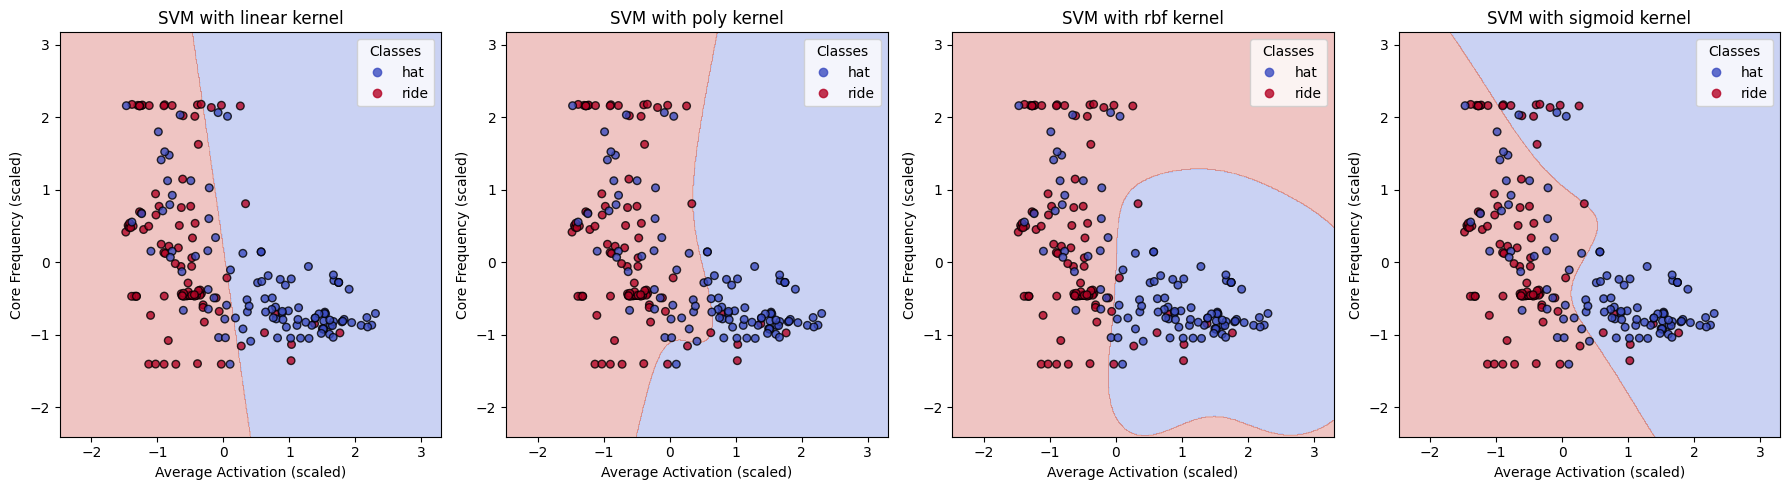

In [ ]:
data = pd.read_csv('/content/drive/MyDrive/sample_features_balanced.csv')
filtered_data = data[data['label'].isin(['ride', 'hat'])]
visualization_accuracies = []

X = filtered_data[['average_activation', 'core_frequency']]
y = filtered_data['label']

mapping = {'ride': 0, 'hat': 1}
y_mapped = y.map(mapping)

X_train, X_test, y_train, y_test = train_test_split(X, y_mapped, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

kernels = ['linear', 'poly', 'rbf','sigmoid']
models = {}

for kernel in kernels:
    model = SVC(kernel=kernel, degree=3 if kernel == 'poly' else 1, probability=True)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    models[kernel] = {
        'model': model,
        'accuracy': accuracy_score(y_test, y_pred),
        'conf_matrix': confusion_matrix(y_test, y_pred),
        'classification_report': classification_report(y_test, y_pred, target_names=['ride', 'hat'])
    }

for kernel, data in models.items():
    print(f"\nKernel: {kernel}")
    print(f"Accuracy: {data['accuracy']:.2f}")
    visualization_accuracies.append(data['accuracy'])
    print("Confusion Matrix:\n", data['conf_matrix'])
    print("Classification Report:\n", data['classification_report'])
visualization_accuracies.append(np.mean(visualization_accuracies))
fig, axes = plt.subplots(1, len(kernels), figsize=(18, 5))

X_scaled = scaler.transform(X)

for i, kernel in enumerate(kernels):
    model = models[kernel]['model']
    ax = axes[i] if len(kernels) > 1 else axes
    ax.set_title(f"SVM with {kernel} kernel")

    x_min, x_max = X_scaled[:, 0].min() - 1, X_scaled[:, 0].max() + 1
    y_min, y_max = X_scaled[:, 1].min() - 1, X_scaled[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))

    mesh_points = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(mesh_points)
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)

    scatter = ax.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_mapped, cmap=plt.cm.coolwarm,
                         s=30, edgecolor='k', alpha=0.8)

    handles, _ = scatter.legend_elements()
    class_labels = ['hat', 'ride']
    ax.legend(handles, class_labels, title="Classes", loc="upper right")

    ax.set_xlabel('Average Activation (scaled)')
    ax.set_ylabel('Core Frequency (scaled)')

plt.tight_layout()
plt.show()


## SVM Visualization Results

Here are some observations I made about the results for each of the kernels:\
\
Linear - Many blue hat samples are misclassified due to the substantial overlap of the two classes. With an accuracy value of 0.77, it is the most accurate model despite misclassifying many blue dots and a few red dots. \

Polynomial - The curve of the decision boundary did not help with more accurately classifying points as compared to the linear kernel, with an accuracy value of 0.74. Visually it seems like the sharpest point of the curve in the boundary couldn't have reasonably gone anywhere else, so a lot of extra blue points were included in the red side of the hyperplane.\

RBF - The enclosed shape that makes up the blue side of the decision boundary visually seems to be quite effective at classifying the bulk of the hat samples, but with an accuracy value of 0.76 it is actually extremely similar in performance to the linear kernel. This is likely because similarly to the linear kernel boundary, many blue hat samples are misclassified.\

Sigmoid - Since the sigmoid kernel is typically used in higher dimensions to take full advantage of the hyperbolic tangent function's irregular transformation of data, it was by far the worst performing kernel in this demonstration with an accuracy value of 0.71. Visually, the decision boundary appears to curve way more than is necessary at the cost of misclassifying many more red ride samples. The precision value for the ride samples was a very low 0.77, which is almost 0.1 behind the other kernels. This confirms the visual intuition that the sigmoid kernel poorly classified ride samples in this demonstration.




## Binary SVM classification with hyperplane

Below is an extension of the previous demonstration, but instead of classifying two classes on two features I am using all four features from our dataset. I am also performing a form of cross validation by performing SVC across kernels on 10 different random training and testing splits, and reporting the best accuracy across the 10 iterations for each kernel.

In [ ]:
data = pd.read_csv('/content/drive/MyDrive/sample_features_balanced.csv')
filtered_data = data[data['label'].isin(['ride', 'hat'])]
binary_accuracies = []

X = filtered_data[['core_frequency', 'max_amplitude', 'average_activation', 'duration']]
y = filtered_data['label']

kernels = ['linear', 'poly', 'rbf', 'sigmoid']

np.random.seed(445)
random_seeds = np.random.randint(0, 100000, size=10)

best_models = {}

for kernel in kernels:
    best_accuracy = 0
    best_model = None
    best_conf_matrix = None
    best_classification_report = None
    best_random_seed = None

    for i in range(10):

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=random_seeds[i])

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        model = SVC(kernel=kernel, degree=3 if kernel == 'poly' else 1, random_state=random_seeds[i])
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)

        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_model = model
            best_conf_matrix = confusion_matrix(y_test, y_pred)
            best_classification_report = classification_report(y_test, y_pred, target_names=['ride', 'hat'])
            best_random_seed = random_seeds[i]

    best_models[kernel] = {
        'model': best_model,
        'accuracy': best_accuracy,
        'conf_matrix': best_conf_matrix,
        'classification_report': best_classification_report,
        'random_seed': best_random_seed
    }

for kernel, result in best_models.items():
    print(f"\nKernel: {kernel}")
    print(f"Best Accuracy: {result['accuracy']:.2f}")
    binary_accuracies.append(result['accuracy'])
    print(f"Random Seed for Best Iteration: {result['random_seed']}")
    print("Confusion Matrix:\n", result['conf_matrix'])
    print("Classification Report:\n", result['classification_report'])
binary_accuracies.append(np.mean(binary_accuracies))


Kernel: linear
Best Accuracy: 0.95
Random Seed for Best Iteration: 83744
Confusion Matrix:
 [[31  1]
 [ 2 28]]
Classification Report:
               precision    recall  f1-score   support

        ride       0.94      0.97      0.95        32
         hat       0.97      0.93      0.95        30

    accuracy                           0.95        62
   macro avg       0.95      0.95      0.95        62
weighted avg       0.95      0.95      0.95        62


Kernel: poly
Best Accuracy: 0.95
Random Seed for Best Iteration: 83744
Confusion Matrix:
 [[32  0]
 [ 3 27]]
Classification Report:
               precision    recall  f1-score   support

        ride       0.91      1.00      0.96        32
         hat       1.00      0.90      0.95        30

    accuracy                           0.95        62
   macro avg       0.96      0.95      0.95        62
weighted avg       0.96      0.95      0.95        62


Kernel: rbf
Best Accuracy: 0.97
Random Seed for Best Iteration: 83744
Confu

## Binary SVM results

The most important result of this demonstration is that with many informational features and only two classes, SVM can perform very well regardless of the kernel used. The sigmoid kernel was still significantly behind the others, which is still likely the result of too few dimensions/classes.

## SVM with hyperplane on full dataset

 SVC was initially designed with binary classification in mind, but the use of one-vs-one classification allows for many different classes to be classified by the same SVC model. One-vs-one SVC works by doing binary classification between all possible pairs of classes, and gives overall statistics for each pair. This demonstration is only slightly different than the previous one because it uses all four classes are used instead of only two.

In [ ]:
full_accuracies = []

X = data[['core_frequency', 'max_amplitude', 'average_activation', 'duration']]
y = data['label']

kernels = ['linear', 'poly', 'rbf', 'sigmoid']
best_models = {}
np.random.seed(445)
random_seed = np.random.randint(0, 100000, size=10)

for kernel in kernels:
    best_accuracy = 0
    best_model = None
    best_conf_matrix = None
    best_classification_report = None
    best_random_seed = None


    for i in range(10):

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=random_seed[i])

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        model = SVC(kernel=kernel, degree=3 if kernel == 'poly' else 1, random_state=random_seed[i])
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)

        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_model = model
            best_conf_matrix = confusion_matrix(y_test, y_pred)
            best_classification_report = classification_report(y_test, y_pred)
            best_random_seed = random_seed[i]

    best_models[kernel] = {
        'model': best_model,
        'accuracy': best_accuracy,
        'conf_matrix': best_conf_matrix,
        'classification_report': best_classification_report,
        'random_seed': best_random_seed
    }

for kernel, result in best_models.items():
    print(f"\nKernel: {kernel}")
    print(f"Best Accuracy: {result['accuracy']:.2f}")
    full_accuracies.append(result['accuracy'])
    print(f"Random Seed for Best Iteration: {result['random_seed']}")
    print("Confusion Matrix:\n", result['conf_matrix'])
    print("Classification Report:\n", result['classification_report'])
full_accuracies.append(np.mean(full_accuracies))


Kernel: linear
Best Accuracy: 0.84
Random Seed for Best Iteration: 44911
Confusion Matrix:
 [[19  1  0  0]
 [ 1 32  2  0]
 [ 6  2 28  1]
 [ 3  2  2 25]]
Classification Report:
               precision    recall  f1-score   support

         hat       0.66      0.95      0.78        20
        kick       0.86      0.91      0.89        35
        ride       0.88      0.76      0.81        37
       snare       0.96      0.78      0.86        32

    accuracy                           0.84       124
   macro avg       0.84      0.85      0.83       124
weighted avg       0.86      0.84      0.84       124


Kernel: poly
Best Accuracy: 0.79
Random Seed for Best Iteration: 23741
Confusion Matrix:
 [[24  0  2  2]
 [ 1 23  0  7]
 [ 1  0 26  8]
 [ 0  3  2 25]]
Classification Report:
               precision    recall  f1-score   support

         hat       0.92      0.86      0.89        28
        kick       0.88      0.74      0.81        31
        ride       0.87      0.74      0.80     

## Full SVM Results

When using all four features as well as all four classes, the SVC algorithm performed quite well with the linear kernel and to a less extent the RBF kernel. An interesting difference between the kernels in this demonstration is that while the linear kernel was very easily classifying snare samples at an f1-score of 0.86, it struggled with accurately classifying hat samples with an f1-score of 0.78. This is in contrast to all three of the other kernels having a very low f1-score for snare samples and a relatively high f1-score for hat samples. While the high dimensionality reduces my ability to intuit why this is the case, it is clear that the use of different kernels can produce significantly different outputs within the same dataset. This means that if it was much more important to correctly classify hats than snares, then the polynomial or RBF kernels are better suited for the task despite having lower overall accuracy values.

## SVM with one feature removed

This demonstration is similar to the last, with the only difference being the removal of the "duration" feature. The reason for removing duration specifically is because we suspected that the length of the audio file might not necessarily be correlated with the type of drum sample. Performing SVC without duration as a feature should be able to give insight about how important duration actually is in support vector classification.

In [ ]:
data = pd.read_csv('/content/drive/MyDrive/sample_features_balanced.csv')
three_accuracies = []

X = data[['core_frequency', 'max_amplitude', 'average_activation']]
y = data['label']

kernels = ['linear', 'poly', 'rbf', 'sigmoid']
best_models = {}
np.random.seed(445)
random_seed = np.random.randint(0, 100000, size=10)

for kernel in kernels:
    best_accuracy = 0
    best_model = None
    best_conf_matrix = None
    best_classification_report = None
    best_random_seed = None


    for i in range(10):

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=random_seed[i])

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        model = SVC(kernel=kernel, degree=3 if kernel == 'poly' else 1, random_state=random_seed[i])
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)

        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_model = model
            best_conf_matrix = confusion_matrix(y_test, y_pred)
            best_classification_report = classification_report(y_test, y_pred)
            best_random_seed = random_seed[i]

    best_models[kernel] = {
        'model': best_model,
        'accuracy': best_accuracy,
        'conf_matrix': best_conf_matrix,
        'classification_report': best_classification_report,
        'random_seed': best_random_seed
    }

for kernel, result in best_models.items():
    print(f"\nKernel: {kernel}")
    print(f"Best Accuracy: {result['accuracy']:.2f}")
    three_accuracies.append(result['accuracy'])
    print(f"Random Seed for Best Iteration: {result['random_seed']}")
    print("Confusion Matrix:\n", result['conf_matrix'])
    print("Classification Report:\n", result['classification_report'])
three_accuracies.append(np.mean(three_accuracies))


Kernel: linear
Best Accuracy: 0.73
Random Seed for Best Iteration: 44911
Confusion Matrix:
 [[17  1  2  0]
 [ 2 33  0  0]
 [11  0 18  8]
 [ 4  2  3 23]]
Classification Report:
               precision    recall  f1-score   support

         hat       0.50      0.85      0.63        20
        kick       0.92      0.94      0.93        35
        ride       0.78      0.49      0.60        37
       snare       0.74      0.72      0.73        32

    accuracy                           0.73       124
   macro avg       0.74      0.75      0.72       124
weighted avg       0.76      0.73      0.73       124


Kernel: poly
Best Accuracy: 0.71
Random Seed for Best Iteration: 44911
Confusion Matrix:
 [[17  1  1  1]
 [ 1 23  1 10]
 [ 9  0 23  5]
 [ 2  2  3 25]]
Classification Report:
               precision    recall  f1-score   support

         hat       0.59      0.85      0.69        20
        kick       0.88      0.66      0.75        35
        ride       0.82      0.62      0.71     

## Limited Feature SVM Results

The results of this demonstration seem to disprove our hypothesis that duration might not be an important feature for SVC, because accuracies across all kernels are significantly lower than in the same model but with duration added. An exception to this rule of lower accuracies is that the linear kernel's kick classification had an f1-score of 0.93 as compared to the full model's 0.89. This means that for classifying kick samples vs everything else, this limited model would still be quite accurate with a linear kernel. However, this fact still does not make up for the significant loss in accuracy in just about every other category.

## Combined demonstration statistics

                        Linear      Poly       RBF   Sigmoid   Average
Binary w/ 2 features  0.774194  0.741935  0.758065  0.709677  0.745968
Binary w/ 4 features  0.951613  0.951613  0.967742  0.887097  0.939516
Full 4 Feature SVM    0.838710  0.790323  0.806452  0.782258  0.804435
SVM without Duration  0.733871  0.709677  0.750000  0.596774  0.697581


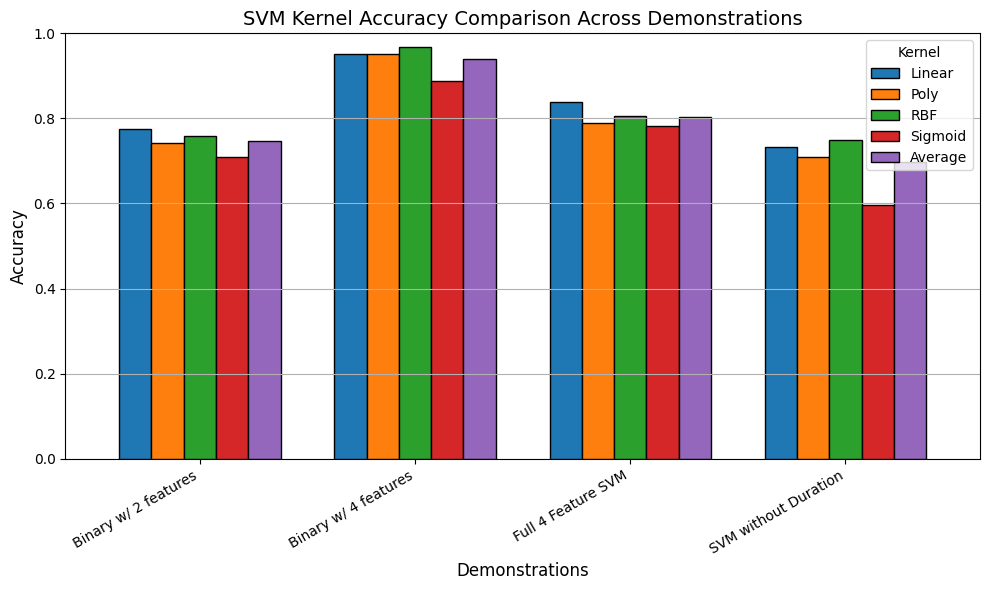

In [ ]:
final_accuracies_list = [visualization_accuracies, binary_accuracies, full_accuracies, three_accuracies]
final_df = pd.DataFrame(final_accuracies_list, columns=["Linear", "Poly", "RBF", "Sigmoid","Average"],
    index=["Binary w/ 2 features", "Binary w/ 4 features", "Full 4 Feature SVM", "SVM without Duration"])

print(final_df)

final_df.plot(kind="bar", figsize=(10, 6), width=0.75, edgecolor="black")
plt.title("SVM Kernel Accuracy Comparison Across Demonstrations", fontsize=14)
plt.ylabel("Accuracy", fontsize=12)
plt.xlabel("Demonstrations", fontsize=12)
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.legend(title="Kernel")
plt.grid(axis="y")

plt.tight_layout()
plt.show()

## Conclusion

The overall results of the four demonstrations were not necessarily surprising, with the SVC model with 4 features and 2 classes performing the best, followed by SVC with 4 features and 4 classes, followed by SVC with 2 features and 2 classes, and SVC with 3 features and 4 classes performing the worst. The reason this result is not surprising is because all four of our features encode a good amount of information, so generally the more features included the better. Of models with the same number of features, the one with fewer classes to classify will generally perform better on this dataset due to the large amonut of overlap between classes.

When comparing kernel results within each demonstration, it is clear that the linear kernel is generally best for classifying all four classes on the full dataset. I believe that this dataset is well suited for the use of the linear kernel because while there is overlap between classes, the classes do not overlap or cluster enough for kernels to be effective. Classifying a dataset with less variance within classes would likely provide the right conditions for transformational kernels to perform better than the linear kernel on average.

Finally, I conclude that SVC is a valid approach to classifying the four classes in our dataset with an accuracy value of 0.83 for the linear kernel and an average accuracy of 0.8 across all kernels.

References:\
Yadav, Suraj. “What Is Kernel Trick in SVM ? Interview Questions Related to Kernel Trick.” Medium, 29 Apr. 2023, https://medium.com/@Suraj_Yadav/what-is-kernel-trick-in-svm-interview-questions-related-to-kernel-trick-97674401c48d.